In [1]:
import pandas as pd
import numpy as np
from skimage import measure
import matplotlib.pyplot as plt

In [29]:
df = pd.read_csv('metadata.csv')

print(f'Data Loaded: {df.shape[0]} rows, {df.shape[1]} cols')

# Only relevent data

df = df.loc[:, ['patient_id', 'img_id', 'diagnostic']]
df.head(3)

Data Loaded: 2298 rows, 26 cols


,patient_id,img_id,diagnostic
0,PAT_1516,PAT_1516_1765_530.png,NEV
1,PAT_46,PAT_46_881_939.png,BCC
2,PAT_1545,PAT_1545_1867_547.png,ACK


In [30]:
# Function to filter valid mask
from skimage import measure

def valid_mask(filename:str) -> bool:
    '''Identifies valid masks given some constraints.'''
    
    valid = False
    path_mask = 'masks/' + filename.replace('.png', '_mask.png')

    try:
        mask = plt.imread(path_mask)
    except FileNotFoundError:
        return np.nan, np.nan

    # convert to binary
    binary_mask = (mask > 0.5).astype(bool)

    # label regions
    labeled = measure.label(binary_mask)
    props = measure.regionprops(labeled)
    sorted_props = sorted(props, key = lambda r: r.area, reverse = True)
    condition = False
    
    if len(props) > 1:
        condition = sorted_props[0].area >= 3*sorted_props[1].area

    if len(props) == 1 or condition:
        valid = True
    
    return valid, len(props)

data = df['img_id'].apply(valid_mask)
df['Valid_mask'] = [x[0] for x in data]
df['number_of_regions'] = [x[1] for x in data]

KeyboardInterrupt: 

In [3]:
df = pd.read_csv('new_metadata.csv', index_col = 0 )

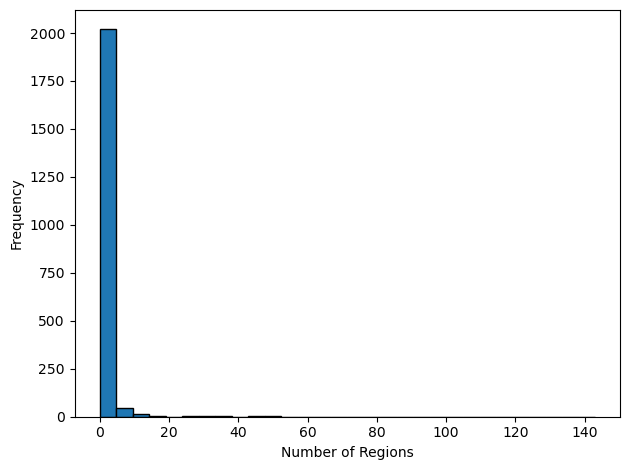

In [4]:
# ======================================
# SPOT OUTLIERS
# ======================================

# VISUAL INSPECTION 

fig = plt.figure()
data = df.number_of_regions
plt.hist(data, bins=30, edgecolor='black')
plt.xlabel('Number of Regions')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


In [5]:
def outliers(data):
    '''returns outliers of the given data'''
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    upper_limit = Q3 + IQR

    return data[data > upper_limit]

In [6]:
# Modified mask for more than one regions.
from skimage import measure

def modified_mask(mask):
    
    # convert to binary
    binary_mask = (mask > 0.5).astype(bool)

    # label regions
    labeled = measure.label(binary_mask)
    props = measure.regionprops(labeled)

    # Find region with maximum area
    largest_region = max(props, key = lambda r: r.area)

    # Extract its label
    largest_label = largest_region.label

    # Create mask for that region
    largest_mask = (labeled == largest_label).astype(bool)

    aux_mask = binary_mask.copy()
    aux_mask[largest_mask] = False

    return np.logical_xor(binary_mask, aux_mask)


In [7]:
def show_img_mask(filename):
    '''Displays the image with its corresponding mask'''
    
    path_img = 'imgs/' + filename
    path_mask = 'masks/' + filename.replace('.png', '_mask.png')
    
    try:
        img, mask = plt.imread(path_img), plt.imread(path_mask)
    except FileNotFoundError:
        return

    before_mask = (mask > 0.5).astype(bool)
    after_mask = modified_mask(before_mask)

    fig, ax = plt.subplots(1,3, figsize = (10,8))

    # plot image
    ax[0].imshow(img)
    ax[0].axis('off')
    ax[0].set_title(filename)

    # plot before mask
    ax[1].imshow(before_mask, cmap='grey')
    ax[1].axis('off')
    ax[1].set_title('Before')

    # plot after mask
    ax[2].imshow(after_mask, cmap='grey')
    ax[2].axis('off')
    ax[2].set_title("After")

    plt.tight_layout()
    plt.show()

In [8]:
df.head()

,patient_id,img_id,diagnostic,Valid_mask,number_of_regions
0,PAT_1516,PAT_1516_1765_530.png,NEV,True,1
1,PAT_46,PAT_46_881_939.png,BCC,True,1
2,PAT_1545,PAT_1545_1867_547.png,ACK,True,1
3,PAT_1989,PAT_1989_4061_934.png,ACK,True,1
4,PAT_684,PAT_684_1302_588.png,BCC,True,1


In [9]:
df[(df.Valid_mask == False) & (df.number_of_regions > 2)].sort_values(by = 'number_of_regions', ascending = False)

,patient_id,img_id,diagnostic,Valid_mask,number_of_regions
1398,PAT_87,PAT_87_133_810.png,SEK,False,28
603,PAT_1491,PAT_1491_1703_637.png,ACK,False,26
1357,PAT_738,PAT_738_1552_843.png,SEK,False,17
1866,PAT_93,PAT_93_361_51.png,SEK,False,16
443,PAT_999,PAT_999_20_540.png,ACK,False,16
...,...,...,...,...,...
472,PAT_1036,PAT_1036_169_687.png,ACK,False,3
312,PAT_259,PAT_259_399_801.png,SCC,False,3
236,PAT_839,PAT_839_1591_204.png,NEV,False,3
1438,PAT_245,PAT_245_376_197.png,BCC,False,3


In [10]:
df = pd.read_csv('new_metadata.csv', index_col = 0)
df = df[df['Valid_mask'] == True]
df.shape


(1945, 5)

In [11]:
feature_df = df.loc[:,['patient_id', 'img_id', 'diagnostic']]
features = ['feature_A', 'feature_B', 'feature_C', 'feature_D']
feature_df['mask_id'] = df['img_id'].str.replace('.png', '_mask.png')

for f in features:
    feature_df[f] = 0

    
feature_df

,patient_id,img_id,diagnostic,mask_id,feature_A,feature_B,feature_C,feature_D
0,PAT_1516,PAT_1516_1765_530.png,NEV,PAT_1516_1765_530_mask.png,0,0,0,0
1,PAT_46,PAT_46_881_939.png,BCC,PAT_46_881_939_mask.png,0,0,0,0
2,PAT_1545,PAT_1545_1867_547.png,ACK,PAT_1545_1867_547_mask.png,0,0,0,0
3,PAT_1989,PAT_1989_4061_934.png,ACK,PAT_1989_4061_934_mask.png,0,0,0,0
4,PAT_684,PAT_684_1302_588.png,BCC,PAT_684_1302_588_mask.png,0,0,0,0
...,...,...,...,...,...,...,...,...
2098,PAT_386,PAT_386_785_536.png,ACK,PAT_386_785_536_mask.png,0,0,0,0
2099,PAT_273,PAT_273_421_905.png,BCC,PAT_273_421_905_mask.png,0,0,0,0
2100,PAT_491,PAT_491_934_46.png,SCC,PAT_491_934_46_mask.png,0,0,0,0
2101,PAT_46,PAT_46_880_140.png,BCC,PAT_46_880_140_mask.png,0,0,0,0


In [6]:
mask_path = 'masks/' + feature_df['img_id'][0].replace('.png', '_mask.png')


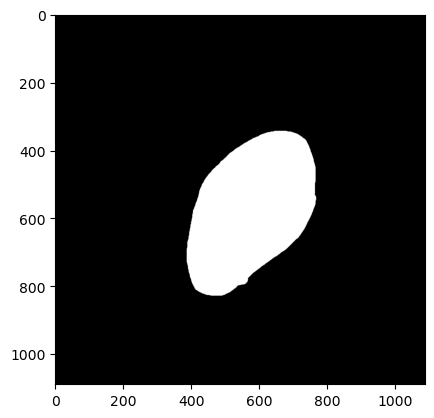

In [7]:
mask = plt.imread(mask_path)
plt.imshow(mask, cmap='grey')


In [12]:
feature_df

,patient_id,img_id,diagnostic,mask_id,feature_A,feature_B,feature_C,feature_D
0,PAT_1516,PAT_1516_1765_530.png,NEV,PAT_1516_1765_530_mask.png,0,0,0,0
1,PAT_46,PAT_46_881_939.png,BCC,PAT_46_881_939_mask.png,0,0,0,0
2,PAT_1545,PAT_1545_1867_547.png,ACK,PAT_1545_1867_547_mask.png,0,0,0,0
3,PAT_1989,PAT_1989_4061_934.png,ACK,PAT_1989_4061_934_mask.png,0,0,0,0
4,PAT_684,PAT_684_1302_588.png,BCC,PAT_684_1302_588_mask.png,0,0,0,0
...,...,...,...,...,...,...,...,...
2098,PAT_386,PAT_386_785_536.png,ACK,PAT_386_785_536_mask.png,0,0,0,0
2099,PAT_273,PAT_273_421_905.png,BCC,PAT_273_421_905_mask.png,0,0,0,0
2100,PAT_491,PAT_491_934_46.png,SCC,PAT_491_934_46_mask.png,0,0,0,0
2101,PAT_46,PAT_46_880_140.png,BCC,PAT_46_880_140_mask.png,0,0,0,0


In [13]:
feature_df['img_id'][0]

'PAT_1516_1765_530.png'

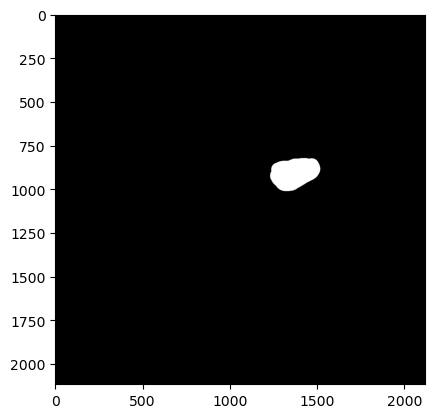

In [24]:
mask = plt.imread('masks/PAT_1989_4061_934_mask.png')
plt.imshow(mask, cmap='grey');

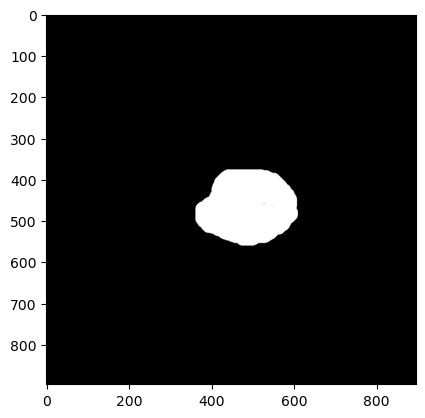

In [25]:
mask = plt.imread('masks/PAT_684_1302_588_mask.png')
plt.imshow(mask, cmap='grey');

In [14]:
data = pd.read_csv('../src/featureDf.csv', index_col = 0)

In [15]:
data

,patient_id,img_id,diagnostic,feature_A,feature_B,feature_C,feature_D
0,PAT_1516,PAT_1516_1765_530.png,NEV,0.743445,0.770187,0,98
1,PAT_46,PAT_46_881_939.png,BCC,0.735339,0.577868,0,136
2,PAT_1545,PAT_1545_1867_547.png,ACK,0.679150,0.615177,0,145
3,PAT_1989,PAT_1989_4061_934.png,ACK,0.676532,0.751758,0,34
4,PAT_684,PAT_684_1302_588.png,BCC,0.876090,0.807628,0,71
...,...,...,...,...,...,...,...
2098,PAT_386,PAT_386_785_536.png,ACK,0.764957,0.774714,0,91
2099,PAT_273,PAT_273_421_905.png,BCC,0.894994,0.847912,0,151
2100,PAT_491,PAT_491_934_46.png,SCC,0.918746,0.874703,0,110
2101,PAT_46,PAT_46_880_140.png,BCC,0.793183,0.774303,0,109


In [19]:
data.sort_values(by = 'feature_D', ascending = False).head(10)

,patient_id,img_id,diagnostic,feature_A,feature_B,feature_C,feature_D
2007,PAT_488,PAT_488_931_321.png,BCC,0.916617,0.769903,0,256
1427,PAT_601,PAT_601_1147_889.png,BCC,0.744493,0.270139,0,256
1470,PAT_386,PAT_386_1554_280.png,BCC,0.644408,0.254461,0,256
1780,PAT_419,PAT_419_833_148.png,SCC,0.733031,0.469130,0,256
82,PAT_1725,PAT_1725_3222_943.png,ACK,0.675105,0.646420,0,256
657,PAT_1074,PAT_1074_322_242.png,ACK,0.722950,0.610161,0,256
1793,PAT_263,PAT_263_1480_753.png,ACK,0.616911,0.568981,0,255
2004,PAT_553,PAT_553_1049_461.png,BCC,0.748871,0.713530,0,255
664,PAT_1402,PAT_1402_1377_799.png,ACK,0.446723,0.257839,0,255
1124,PAT_1563,PAT_1563_2426_436.png,ACK,0.675983,0.523315,0,254


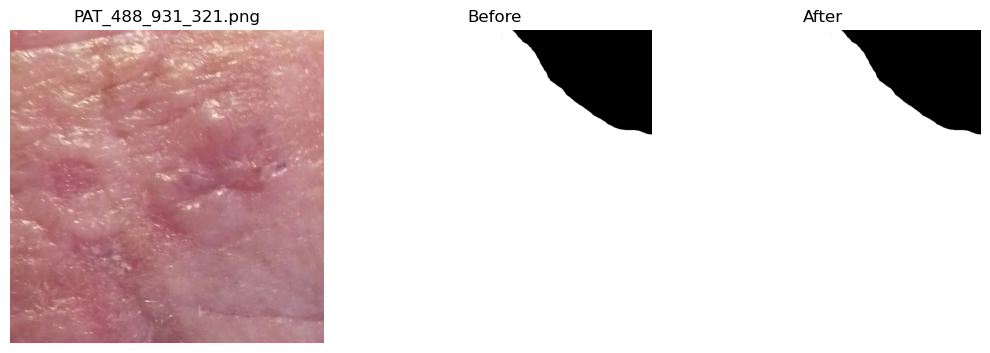

In [28]:
show_img_mask('PAT_488_931_321.png')

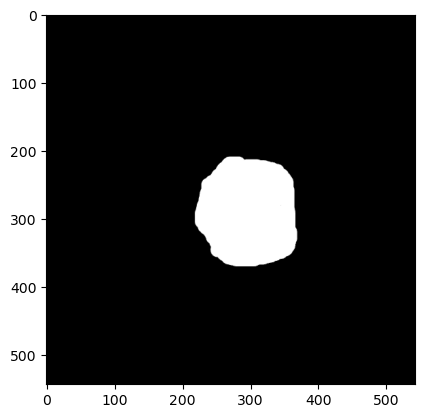

In [51]:
mask = plt.imread('masks/PAT_326_690_823_mask.png')
plt.imshow(mask, cmap='grey');

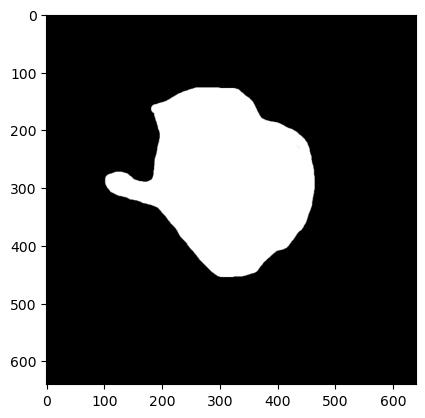

In [52]:
mask = plt.imread('masks/PAT_1545_1867_547_mask.png')
plt.imshow(mask, cmap='grey');

In [43]:
data.feature_A.median()

0.7991553930229531

In [29]:
import seaborn as sns

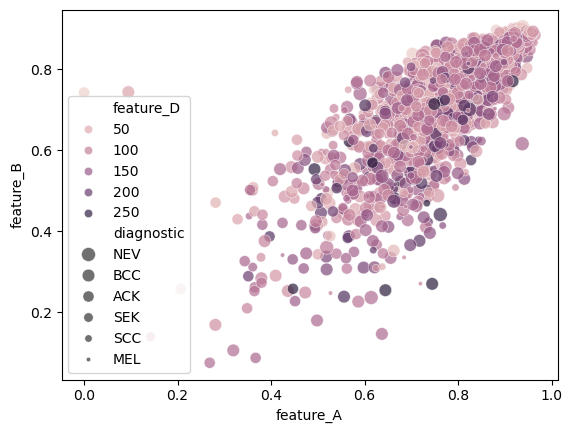

In [51]:
sns.scatterplot(data = data, x = 'feature_A', y = 'feature_B', size = 'diagnostic', hue= 'feature_D', alpha = 0.7, sizes = (10,100), legend = 'auto');

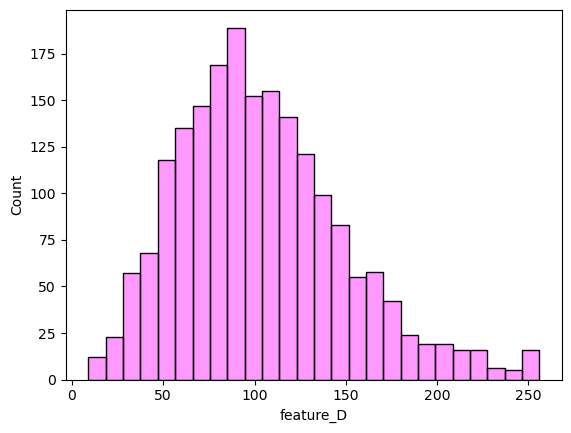

In [50]:
sns.histplot(data = data, x = 'feature_D', kde = False, color = 'magenta', alpha = 0.4);